# DAG Properties: Named Theorems vs. Other Propositions

Comparing graph-theoretic properties of **named theorems** (those whose docstring
contains `**bold**` markup identifying them by name, e.g. Cayley-Hamilton)
against all other LinearAlgebra propositions.

**Statistical test**: Mann-Whitney U (non-parametric, handles skewed distributions
and unequal group sizes). Effect size: rank-biserial correlation *r* ∈ [-1, 1],
where +1 means named theorems always rank higher.

**Caveat**: the named group has only ~30 members — tests will detect large effects
reliably but will miss subtle differences. Visualisations and effect sizes matter
more than p-values here.

In [4]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import duckdb
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

ROOT = Path().resolve().parent
db = duckdb.connect(str(ROOT / 'data' / 'mathlib.db'), read_only=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## 1. Load nodes and labels

In [5]:
# All LA declarations that appear in the proof graph
nodes_df = db.execute("""
    SELECT
        d.name,
        d.kind,
        d.module,
        d.module_parts[3] AS subarea,
        ds.docstring IS NOT NULL                                     AS has_doc,
        regexp_matches(COALESCE(ds.docstring,''), '\\*\\*[^*]+\\*\\*') AS is_named
    FROM declarations d
    LEFT JOIN docstrings ds ON d.name = ds.name
    WHERE d.module LIKE 'Mathlib.LinearAlgebra%'
      AND d.in_leandojo
""").df()

print(f"Nodes: {len(nodes_df):,}")
print(nodes_df['is_named'].value_counts().rename({True:'named', False:'unnamed'}).to_string())

Nodes: 7,263
is_named
unnamed    7233
named        30


## 2. Build the graph and compute structural metrics

In [6]:
la_names = set(nodes_df['name'])

# ── edges ─────────────────────────────────────────────────────────────────
# Internal edges: both src and dst are LA nodes
internal_edges = db.execute("""
    SELECT dep.src, dep.dst
    FROM dependencies dep
    JOIN declarations s ON dep.src = s.name
    JOIN declarations d ON dep.dst = d.name
    WHERE s.module LIKE 'Mathlib.LinearAlgebra%'
      AND d.module LIKE 'Mathlib.LinearAlgebra%'
""").df()

print(f"Internal LA→LA edges: {len(internal_edges):,}")

# ── build DiGraph ──────────────────────────────────────────────────────────
G = nx.DiGraph()
G.add_nodes_from(la_names)
G.add_edges_from(zip(internal_edges['src'], internal_edges['dst']))
print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Internal LA→LA edges: 8,969
Graph: 7,277 nodes, 8,969 edges


In [7]:
# ── global degree (all of Mathlib, not just LA) ────────────────────────────
global_deg = db.execute("""
    SELECT
        d.name,
        COUNT(DISTINCT dep_in.src)  AS global_in_degree,
        COUNT(DISTINCT dep_out.dst) AS global_out_degree
    FROM declarations d
    LEFT JOIN dependencies dep_in  ON dep_in.dst  = d.name
    LEFT JOIN dependencies dep_out ON dep_out.src = d.name
    WHERE d.module LIKE 'Mathlib.LinearAlgebra%' AND d.in_leandojo
    GROUP BY d.name
""").df().set_index('name')

# ── tactic steps ───────────────────────────────────────────────────────────
tactic_counts = db.execute("""
    SELECT t.theorem_name AS name, COUNT(*) AS tactic_steps
    FROM tactics t
    JOIN declarations d ON d.name = t.theorem_name
    WHERE d.module LIKE 'Mathlib.LinearAlgebra%'
    GROUP BY t.theorem_name
""").df().set_index('name')

print("Global degree and tactic counts loaded.")

Global degree and tactic counts loaded.


In [8]:
# ── local degree (within LA subgraph) ─────────────────────────────────────
local_in  = dict(G.in_degree())
local_out = dict(G.out_degree())

# ── PageRank ───────────────────────────────────────────────────────────────
print("Computing PageRank…")
pagerank = nx.pagerank(G, alpha=0.85, max_iter=300)

# ── Depth from sources (multi-source BFS) ─────────────────────────────────
# Sources = nodes with local in-degree 0 (nothing within LA points to them)
print("Computing depth from source nodes…")
sources = [n for n in G.nodes() if G.in_degree(n) == 0]
print(f"  {len(sources):,} source nodes (local in-degree 0)")

# BFS from all sources simultaneously on the forward graph
depth_from_source = {n: np.nan for n in G.nodes()}
for src in sources:
    depth_from_source[src] = 0
queue = list(sources)
i = 0
while i < len(queue):
    node = queue[i]
    d = depth_from_source[node]
    for succ in G.successors(node):
        if np.isnan(depth_from_source[succ]):
            depth_from_source[succ] = d + 1
            queue.append(succ)
    i += 1

reachable = sum(1 for v in depth_from_source.values() if not np.isnan(v))
print(f"  {reachable:,} / {len(G):,} nodes reachable from sources")

# ── Height to sinks (BFS on reversed graph) ────────────────────────────────
print("Computing height to sink nodes…")
Gr = G.reverse()
sinks = [n for n in G.nodes() if G.out_degree(n) == 0]
print(f"  {len(sinks):,} sink nodes (local out-degree 0)")

height_to_sink = {n: np.nan for n in G.nodes()}
for sk in sinks:
    height_to_sink[sk] = 0
queue = list(sinks)
i = 0
while i < len(queue):
    node = queue[i]
    h = height_to_sink[node]
    for succ in Gr.successors(node):
        if np.isnan(height_to_sink[succ]):
            height_to_sink[succ] = h + 1
            queue.append(succ)
    i += 1

print("Done.")

Computing PageRank…
Computing depth from source nodes…
  4,099 source nodes (local in-degree 0)
  7,259 / 7,277 nodes reachable from sources
Computing height to sink nodes…
  3,343 sink nodes (local out-degree 0)
Done.


In [9]:
# ── Approximate betweenness centrality ────────────────────────────────────
# k=300 sampled pivots; fast and sufficient for relative ranking
print("Computing approximate betweenness centrality (k=300)…")
betweenness = nx.betweenness_centrality(G, k=300, normalized=True, seed=42)
print("Done.")

Computing approximate betweenness centrality (k=300)…
Done.


In [10]:
# ── Assemble feature DataFrame ─────────────────────────────────────────────
feat = nodes_df.set_index('name').copy()

feat['local_in_degree']   = feat.index.map(local_in)
feat['local_out_degree']  = feat.index.map(local_out)
feat['global_in_degree']  = feat.index.map(global_deg['global_in_degree'])
feat['global_out_degree'] = feat.index.map(global_deg['global_out_degree'])
feat['pagerank']          = feat.index.map(pagerank)
feat['depth']             = feat.index.map(depth_from_source)
feat['height']            = feat.index.map(height_to_sink)
feat['betweenness']       = feat.index.map(betweenness)
feat['tactic_steps']      = feat.index.map(tactic_counts.get('tactic_steps', pd.Series(dtype=float)))
feat['tactic_steps']      = feat['tactic_steps'].fillna(0).astype(int)
feat['is_tactic_proof']   = feat['tactic_steps'] > 0

print(f"Feature matrix: {feat.shape}")
feat[feat['is_named']].head(5)

Feature matrix: (7263, 15)


,kind,module,subarea,has_doc,is_named,local_in_degree,local_out_degree,global_in_degree,global_out_degree,pagerank,depth,height,betweenness,tactic_steps,is_tactic_proof
name,,,,,,,,,,,,,,,
TensorProduct.vanishesTrivially_of_sum_tmul_eq_zero_of_rTensor_injective,theorem,Mathlib.LinearAlgebra.TensorProduct.Vanishing,TensorProduct,True,True,3,6,3,21,0.000162,1.0,1.0,0.000019,14,True
QuadraticForm.equivalent_sign_ne_zero_weighted_sum_squared,theorem,Mathlib.LinearAlgebra.QuadraticForm.Real,QuadraticForm,True,True,0,1,0,1,0.000075,0.0,2.0,0.000000,0,False
Matrix.det_one_add_col_mul_row,theorem,Mathlib.LinearAlgebra.Matrix.SchurComplement,Matrix,True,True,0,2,0,5,0.000075,0.0,3.0,0.000000,1,True
TensorProduct.sum_tmul_eq_zero_of_vanishesTrivially,theorem,Mathlib.LinearAlgebra.TensorProduct.Vanishing,TensorProduct,True,True,1,5,2,7,0.000098,2.0,1.0,0.000003,4,True
rank_range_add_rank_ker,theorem,Mathlib.LinearAlgebra.Dimension.RankNullity,Dimension,True,True,1,2,1,6,0.000098,2.0,1.0,0.000000,2,True


## 3. Statistical comparison: named vs. unnamed

Mann-Whitney U test on each metric.
**Effect size**: rank-biserial correlation *r* = 1 − 2U/(n₁n₂).
Interpretation: r > 0 means named theorems tend to rank higher on this metric.

In [11]:
METRICS = [
    ('global_in_degree',  'Global in-degree (cited anywhere in Mathlib)'),
    ('global_out_degree', 'Global out-degree (total dependencies)'),
    ('local_in_degree',   'Local in-degree (cited within LinearAlgebra)'),
    ('local_out_degree',  'Local out-degree (depends on within LinearAlgebra)'),
    ('pagerank',          'PageRank (recursive importance within LA)'),
    ('depth',             'Depth from source nodes'),
    ('height',            'Height to sink nodes'),
    ('betweenness',       'Betweenness centrality (approx, k=300)'),
    ('tactic_steps',      'Tactic proof length'),
]

named   = feat[feat['is_named']]
unnamed = feat[~feat['is_named']]

print(f"Named: {len(named)}  |  Unnamed: {len(unnamed):,}")
print()

rows = []
for col, label in METRICS:
    a = named[col].dropna().values
    b = unnamed[col].dropna().values
    if len(a) < 3 or len(b) < 3:
        continue
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - 2*u / (len(a)*len(b))   # rank-biserial correlation
    rows.append({
        'metric': label,
        'named median':   np.median(a),
        'unnamed median': np.median(b),
        'effect r':       round(r, 3),
        'p-value':        round(p, 4),
        'sig': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')),
    })

results = pd.DataFrame(rows).set_index('metric')
results

Named: 30  |  Unnamed: 7,233



,named median,unnamed median,effect r,p-value,sig
metric,,,,,
Global in-degree (cited anywhere in Mathlib),1.000000,1.000000,-0.078,0.4266,
Global out-degree (total dependencies),5.000000,2.000000,-0.465,0.0000,***
Local in-degree (cited within LinearAlgebra),1.000000,0.000000,-0.062,0.5165,
Local out-degree (depends on within LinearAlgebra),2.000000,1.000000,-0.444,0.0000,***
PageRank (recursive importance within LA),0.000087,0.000075,-0.036,0.7093,
Depth from source nodes,1.000000,0.000000,-0.134,0.1534,
Height to sink nodes,1.000000,1.000000,-0.390,0.0001,***
"Betweenness centrality (approx, k=300)",0.000000,0.000000,-0.049,0.2416,
Tactic proof length,1.500000,0.000000,-0.314,0.0010,**


In [12]:
# ── Formatted summary table ────────────────────────────────────────────────
def fmt_row(row):
    direction = '↑ named higher' if row['effect r'] > 0.1 else (
                '↓ named lower'  if row['effect r'] < -0.1 else '≈ similar')
    return f"{row['named median']:>10.3g}  {row['unnamed median']:>12.3g}  "\
           f"r={row['effect r']:+.2f}  p={row['p-value']:.4f}{row['sig']:3s}  {direction}"

print(f"{'Metric':<50} {'Named med':>10}  {'Unnamed med':>12}  {'Effect':>6}  {'p-value':>8}     {'Direction'}")
print('─'*115)
for metric, row in results.iterrows():
    print(f"{metric:<50} {fmt_row(row)}")

Metric                                              Named med   Unnamed med  Effect   p-value     Direction
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Global in-degree (cited anywhere in Mathlib)                1             1  r=-0.08  p=0.4266     ≈ similar
Global out-degree (total dependencies)                      5             2  r=-0.47  p=0.0000***  ↓ named lower
Local in-degree (cited within LinearAlgebra)                1             0  r=-0.06  p=0.5165     ≈ similar
Local out-degree (depends on within LinearAlgebra)          2             1  r=-0.44  p=0.0000***  ↓ named lower
PageRank (recursive importance within LA)            8.74e-05      7.48e-05  r=-0.04  p=0.7093     ≈ similar
Depth from source nodes                                     1             0  r=-0.13  p=0.1534     ↓ named lower
Height to sink nodes                                        1             1  r=-0.39  p=0.0001***  ↓ named low

## 4. Visualisations

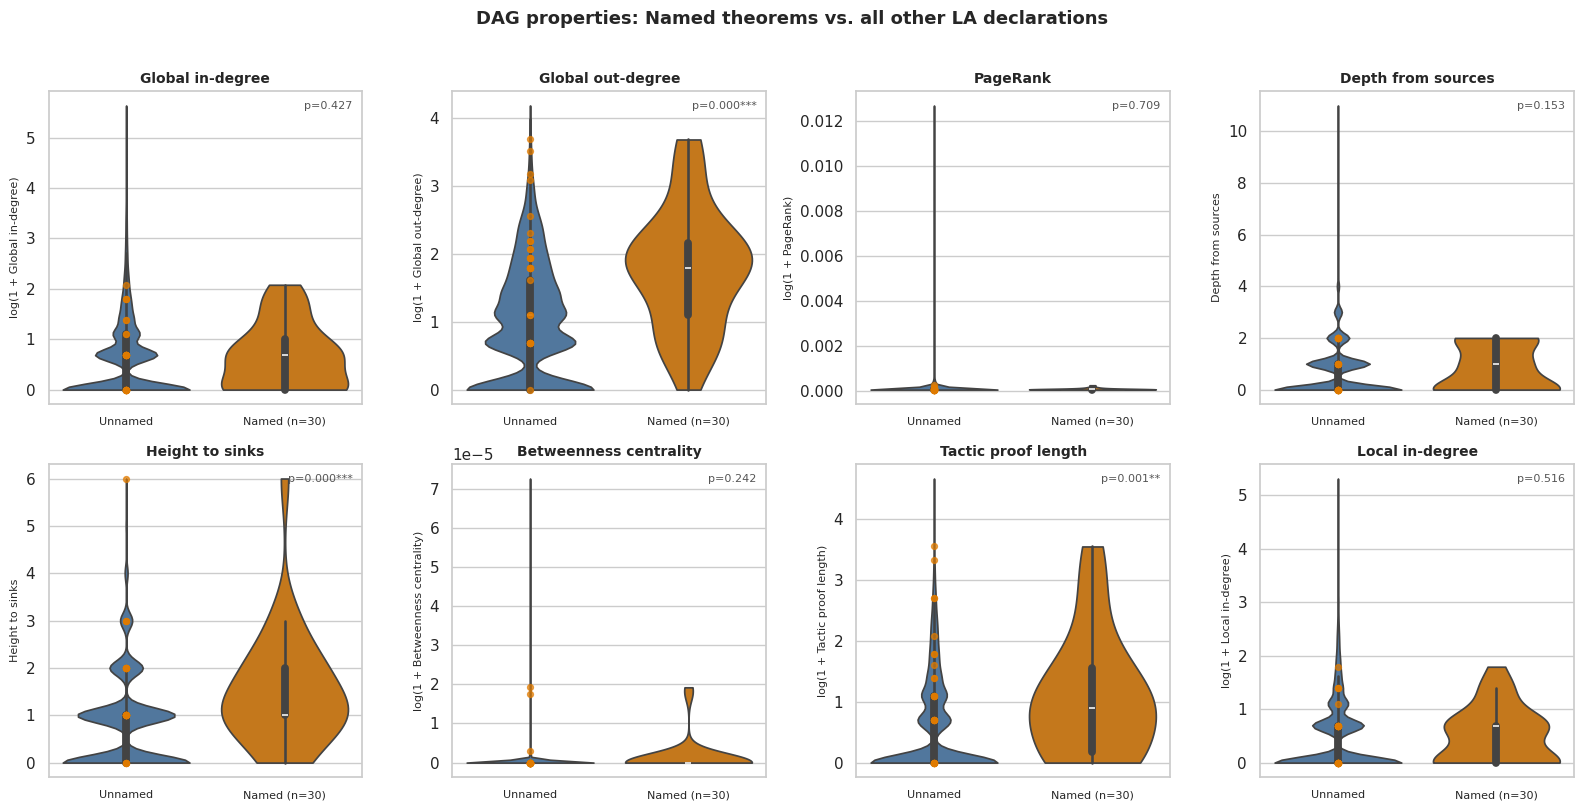

In [13]:
plot_metrics = [
    ('global_in_degree',  'Global in-degree'),
    ('global_out_degree', 'Global out-degree'),
    ('pagerank',          'PageRank'),
    ('depth',             'Depth from sources'),
    ('height',            'Height to sinks'),
    ('betweenness',       'Betweenness centrality'),
    ('tactic_steps',      'Tactic proof length'),
    ('local_in_degree',   'Local in-degree'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plot_df = feat[['is_named'] + [m for m, _ in plot_metrics]].copy()
plot_df['group'] = plot_df['is_named'].map({True: 'Named (n=30)', False: 'Unnamed'})

for ax, (col, label) in zip(axes, plot_metrics):
    sub = plot_df[[col, 'group']].dropna()

    # Log-transform right-skewed metrics for readability
    log_cols = {'global_in_degree', 'global_out_degree', 'pagerank',
                'betweenness', 'tactic_steps', 'local_in_degree'}
    if col in log_cols:
        sub = sub.copy()
        sub[col] = np.log1p(sub[col])
        xlabel = f'log(1 + {label})'
    else:
        xlabel = label

    sns.violinplot(
        data=sub, x='group', y=col, ax=ax,
        palette={'Named (n=30)': '#e07b00', 'Unnamed': '#4477aa'},
        inner='box', cut=0, density_norm='width',
    )
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(xlabel, fontsize=8)
    ax.tick_params(axis='x', labelsize=8)

    # Overlay individual named-theorem points
    named_vals = sub[sub['group'] == 'Named (n=30)'][col]
    ax.scatter(
        np.zeros(len(named_vals)), named_vals,
        color='#e07b00', s=18, zorder=5, alpha=0.7
    )

    # Annotate p-value
    p = results.loc[results.index.str.contains(label[:12])]['p-value']
    if not p.empty:
        sig = results.loc[results.index.str.contains(label[:12])]['sig'].values[0]
        ax.text(0.97, 0.97, f'p={p.values[0]:.3f}{sig}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#555')

plt.suptitle('DAG properties: Named theorems vs. all other LA declarations',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'dag_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Effect size waterfall

Rank-biserial correlation summarised for all metrics.
Positive = named theorems rank higher; negative = rank lower.

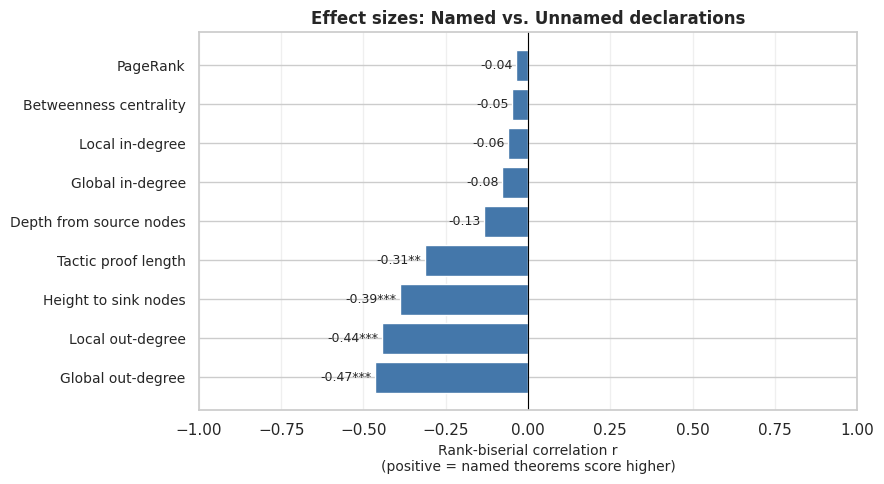

In [14]:
r_vals = results['effect r'].sort_values()
colors = ['#e07b00' if v > 0 else '#4477aa' for v in r_vals]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(r_vals)), r_vals.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(r_vals)))
# Shorten labels for display
short_labels = [l.split('(')[0].strip() for l in r_vals.index]
ax.set_yticklabels(short_labels, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rank-biserial correlation r\n(positive = named theorems score higher)', fontsize=10)
ax.set_title('Effect sizes: Named vs. Unnamed declarations', fontsize=12, fontweight='bold')

for i, (v, sig) in enumerate(zip(r_vals.values, results.loc[r_vals.index, 'sig'])):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:+.2f}{sig}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)

ax.set_xlim(-1, 1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Depth vs. in-degree scatter

Where do named theorems sit in the depth vs. importance space?

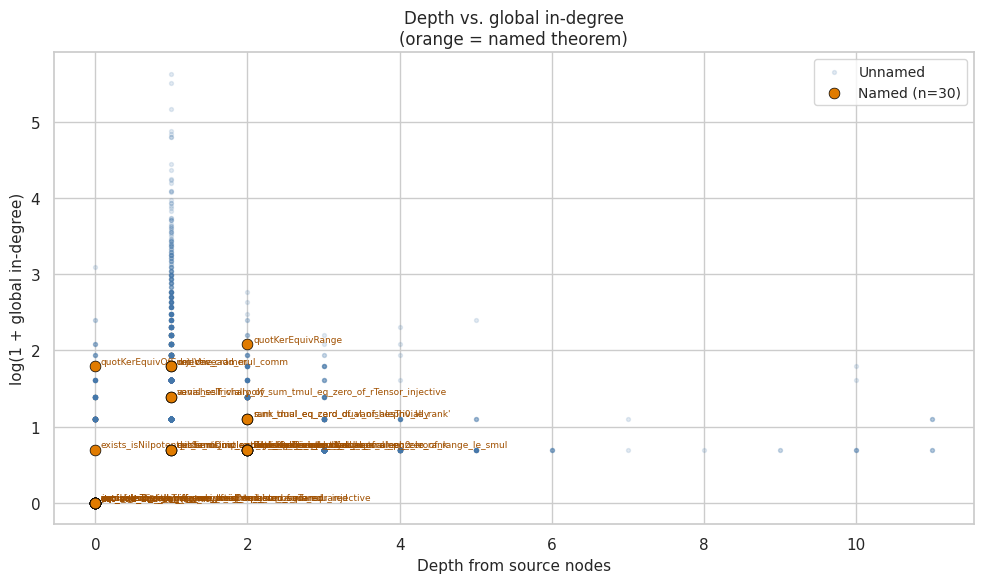

In [15]:
plot_data = feat[['depth', 'global_in_degree', 'pagerank', 'is_named', 'kind']].dropna(
    subset=['depth', 'global_in_degree']
).copy()
plot_data['log_in'] = np.log1p(plot_data['global_in_degree'])

fig, ax = plt.subplots(figsize=(10, 6))

# Background: all unnamed points
u = plot_data[~plot_data['is_named']]
ax.scatter(u['depth'], u['log_in'], c='#4477aa', alpha=0.15, s=8, label='Unnamed')

# Foreground: named theorem points with labels
n = plot_data[plot_data['is_named']]
ax.scatter(n['depth'], n['log_in'], c='#e07b00', s=60, zorder=5,
           edgecolors='black', linewidths=0.5, label=f'Named (n={len(n)})')

# Label each named theorem
for name, row in n.iterrows():
    short = name.split('.')[-1]  # just the last component
    ax.annotate(short, (row['depth'], row['log_in']),
                fontsize=6.5, color='#a05000',
                xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Depth from source nodes', fontsize=11)
ax.set_ylabel('log(1 + global in-degree)', fontsize=11)
ax.set_title('Depth vs. global in-degree\n(orange = named theorem)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'depth_vs_indegree.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Which named theorems are outliers on each metric?

In [16]:
named_df = feat[feat['is_named']].copy()

# For each metric, show the top 5 named theorems
for col, label in [
    ('global_in_degree', 'Most cited globally'),
    ('global_out_degree', 'Most dependencies'),
    ('betweenness', 'Highest betweenness'),
    ('tactic_steps', 'Longest tactic proof'),
    ('depth', 'Deepest (most derived)'),
]:
    top = named_df[col].nlargest(5)
    print(f"\n── {label} ──")
    for name, val in top.items():
        short_name = name
        print(f"  {short_name:<65} {val:.4g}")


── Most cited globally ──
  LinearMap.quotKerEquivRange                                       7
  Matrix.mulVec_cramer                                              5
  Matrix.det_one_add_mul_comm                                       5
  LinearMap.quotKerEquivOfSurjective                                5
  TensorProduct.vanishesTrivially_of_sum_tmul_eq_zero_of_rTensor_injective 3

── Most dependencies ──
  TensorProduct.vanishesTrivially_of_sum_tmul_eq_zero               39
  eigenvalue_mem_ball                                               33
  LinearMap.exists_monic_and_coeff_mem_pow_and_aeval_eq_zero_of_range_le_smul 23
  TensorProduct.vanishesTrivially_of_sum_tmul_eq_zero_of_rTensor_injective 21
  Matrix.aeval_self_charpoly                                        12

── Highest betweenness ──
  TensorProduct.vanishesTrivially_of_sum_tmul_eq_zero_of_rTensor_injective 1.924e-05
  TensorProduct.vanishesTrivially_of_sum_tmul_eq_zero               1.741e-05
  TensorProduct.sum_tmul_eq_z

## 8. Secondary comparison: documented vs. undocumented

Since the named group is small (n=30), a more powerful test compares
declarations **with any docstring** vs. those without.

In [17]:
doc_rows = []
for col, label in METRICS:
    a = feat[feat['has_doc']][col].dropna().values
    b = feat[~feat['has_doc']][col].dropna().values
    if len(a) < 3 or len(b) < 3:
        continue
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - 2*u / (len(a)*len(b))
    doc_rows.append({
        'metric': label,
        'has_doc median':  np.median(a),
        'no_doc median':   np.median(b),
        'effect r': round(r, 3),
        'p-value':  round(p, 4),
        'sig': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')),
    })

doc_results = pd.DataFrame(doc_rows).set_index('metric')
print(f"Documented: {feat['has_doc'].sum():,}  |  Undocumented: {(~feat['has_doc']).sum():,}\n")
doc_results

Documented: 2,453  |  Undocumented: 4,810



,has_doc median,no_doc median,effect r,p-value,sig
metric,,,,,
Global in-degree (cited anywhere in Mathlib),1.000000,0.000000,-0.168,0.0,***
Global out-degree (total dependencies),2.000000,1.000000,-0.129,0.0,***
Local in-degree (cited within LinearAlgebra),1.000000,0.000000,-0.147,0.0,***
Local out-degree (depends on within LinearAlgebra),1.000000,1.000000,-0.091,0.0,***
PageRank (recursive importance within LA),0.000085,0.000075,-0.159,0.0,***
Depth from source nodes,1.000000,0.000000,-0.110,0.0,***
Height to sink nodes,1.000000,1.000000,-0.079,0.0,***
"Betweenness centrality (approx, k=300)",0.000000,0.000000,-0.037,0.0,***
Tactic proof length,0.000000,0.000000,0.084,0.0,***


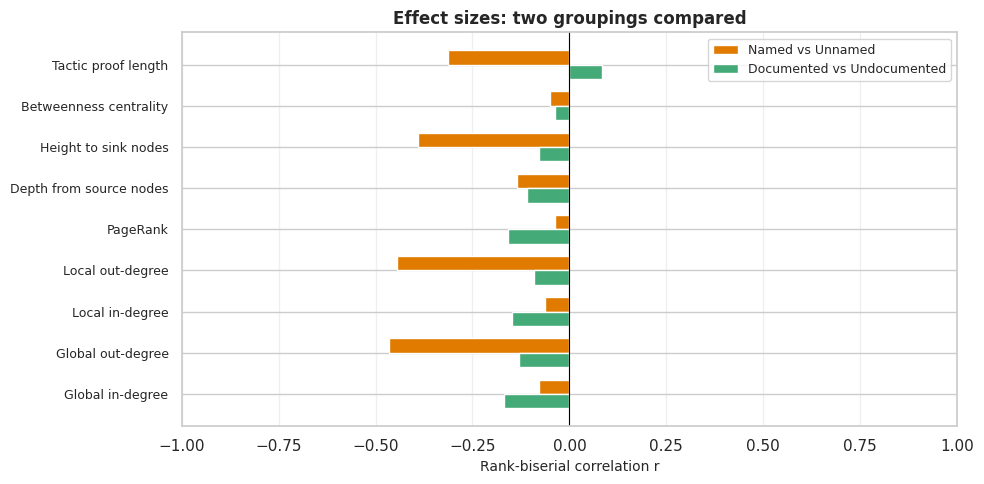

In [18]:
# Side-by-side effect size comparison
combined = pd.DataFrame({
    'Named vs Unnamed (n=30)': results['effect r'],
    'Documented vs Undocumented': doc_results['effect r'],
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(combined))
w = 0.35
ax.barh(x + w/2, combined['Named vs Unnamed (n=30)'],     w, color='#e07b00', label='Named vs Unnamed')
ax.barh(x - w/2, combined['Documented vs Undocumented'],  w, color='#44aa77', label='Documented vs Undocumented')

ax.set_yticks(x)
ax.set_yticklabels([l.split('(')[0].strip() for l in combined.index], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rank-biserial correlation r', fontsize=10)
ax.set_title('Effect sizes: two groupings compared', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-1, 1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'effect_sizes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## View Lean source for any declaration

In [19]:
from IPython.display import display, HTML
import re as _re

COMMIT = "29dcec074de168ac2bf835a77ef68bbe069194c5"

# Lean keyword categories for basic syntax colouring
_KW_DECL    = r'\b(theorem|lemma|def|definition|instance|class|structure|inductive|abbrev|axiom|noncomputable|private|protected|unsafe)\b'
_KW_TACTIC  = r'\b(by|intro|intros|apply|exact|rw|simp|ring|norm_num|linarith|omega|refine|have|obtain|cases|rcases|induction|constructor|use|ext|funext|congr|push_neg|contrapose|tauto|decide|native_decide|aesop|trivial|rfl|assumption|exfalso|left|right|split|fin_cases|interval_cases)\b'
_KW_EXPR    = r'\b(fun|let|in|if|then|else|match|with|return|do|where|deriving|extends|forall|exists|And|Or|Not|True|False|Prop|Type|Sort)\b'
_KW_SYMBOL  = r'(→|←|↔|∀|∃|∧|∨|¬|≤|≥|≠|⟨|⟩|⟦|⟧|‹|›|:=|=>|::|·|∘|∈|∉|⊆|⊇|⊂|⊃|∪|∩|∅|λ)'
_COMMENT    = r'(--[^\n]*)'
_STRING     = r'("(?:[^"\\]|\\.)*")'
_NUMBER     = r'\b(\d+(?:\.\d+)?)\b'

def _highlight_lean(code: str) -> str:
    """Minimal Lean 4 syntax highlighting via regex → HTML spans."""
    code = code.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    rules = [
        (_COMMENT,   'color:#6a737d;font-style:italic'),
        (_STRING,    'color:#032f62'),
        (_KW_DECL,   'color:#d73a49;font-weight:bold'),
        (_KW_TACTIC, 'color:#005cc5'),
        (_KW_EXPR,   'color:#6f42c1'),
        (_KW_SYMBOL, 'color:#e36209'),
        (_NUMBER,    'color:#005cc5'),
    ]
    for pat, style in rules:
        code = _re.sub(pat, lambda m: f'<span style="{style}">{m.group(0)}</span>', code)
    return code


def show_lean(name: str, show_tactic_trace: bool = False) -> None:
    """
    Display the Lean source code (and optional tactic trace) for a declaration.

    Parameters
    ----------
    name              : full Lean name, e.g. 'Matrix.aeval_self_charpoly'
    show_tactic_trace : if True, also render the step-by-step tactic proof states
    """
    row = db.execute(
        "SELECT ls.code, ls.file_path, ls.start_line, ls.end_line, "
        "       d.kind, d.module, ds.docstring "
        "FROM lean_source ls "
        "JOIN declarations d ON d.name = ls.name "
        "LEFT JOIN docstrings ds ON ds.name = ls.name "
        "WHERE ls.name = ?",
        [name]
    ).fetchone()

    if row is None:
        candidates = db.execute(
            "SELECT name FROM lean_source WHERE name LIKE ? LIMIT 8",
            [f'%{name}%']
        ).fetchall()
        if candidates:
            display(HTML(
                f'<div style="font-family:monospace;color:#c00">Not found: <b>{name}</b></div>'
                f'<div style="font-family:monospace;margin-top:6px">Did you mean one of:<ul>'
                + ''.join(f'<li>{r[0]}</li>' for r in candidates)
                + '</ul></div>'
            ))
        else:
            display(HTML(f'<div style="color:#c00">Not found: <b>{name}</b></div>'))
        return

    code, file_path, start_line, end_line, kind, module, docstring = row

    gh_url = (
        f"https://github.com/leanprover-community/mathlib4/blob/{COMMIT}"
        f"/{file_path}#L{start_line}"
        if file_path and start_line else None
    )
    gh_badge = (
        f'<a href="{gh_url}" target="_blank" '
        f'style="font-size:0.75em;background:#24292e;color:#fff;padding:2px 7px;'
        f'border-radius:3px;text-decoration:none;margin-left:10px">View on GitHub ↗</a>'
        if gh_url else ''
    )

    doc_html = ''
    if docstring:
        doc_text = _re.sub(r'\*\*(.+?)\*\*', r'<strong>\1</strong>', docstring)
        doc_text = _re.sub(r'`([^`]+)`', r'<code>\1</code>', doc_text)
        doc_html = (
            f'<div style="margin:6px 0 8px 0;padding:6px 10px;background:#f6f8fa;'
            f'border-left:3px solid #0366d6;font-family:sans-serif;font-size:0.9em;'
            f'white-space:pre-wrap;color:#24292e">{doc_text}</div>'
        )

    highlighted = _highlight_lean(code or '')
    loc = f'{file_path}:{start_line}–{end_line}' if file_path else ''

    html = (
        f'<div style="font-family:monospace;margin:8px 0">'
        f'  <div style="margin-bottom:4px">'
        f'    <span style="font-size:1.1em;font-weight:bold;color:#0366d6">{name}</span>'
        f'    <span style="color:#888;font-size:0.8em;margin-left:8px">{kind or ""} — {module or ""}</span>'
        f'    {gh_badge}'
        f'  </div>'
        f'  <div style="color:#aaa;font-size:0.75em;margin-bottom:4px">{loc}</div>'
        f'  {doc_html}'
        f'  <pre style="background:#f6f8fa;padding:12px;border-radius:4px;'
        f'overflow-x:auto;font-size:0.85em;line-height:1.5;margin:0">{highlighted}</pre>'
        f'</div>'
    )
    display(HTML(html))

    if show_tactic_trace:
        steps = db.execute(
            "SELECT t.tactic_idx, t.tactic_text, t.state_before, t.state_after, "
            "       list(td.premise_name) AS premises "
            "FROM tactics t "
            "LEFT JOIN tactic_deps td ON t.theorem_name=td.theorem_name "
            "  AND t.tactic_idx=td.tactic_idx "
            "WHERE t.theorem_name = ? "
            "GROUP BY t.tactic_idx, t.tactic_text, t.state_before, t.state_after "
            "ORDER BY t.tactic_idx",
            [name]
        ).fetchall()

        if not steps:
            display(HTML('<div style="color:#888;font-style:italic">No tactic trace available '
                         '(term-mode proof or not in LeanDojo splits).</div>'))
            return

        tactic_html = ['<div style="margin-top:12px;font-family:monospace">',
                        '<div style="font-weight:bold;margin-bottom:6px">Tactic trace:</div>',
                        f'<div style="background:#fff8dc;padding:8px;border-radius:4px;'
                        f'font-size:0.82em;margin-bottom:8px;white-space:pre-wrap">'
                        f'<b>Initial goal:</b>\n{steps[0][2]}</div>']

        for idx, tactic, _before, after, prems in steps:
            prems_str = ', '.join(p for p in (prems or []) if p)
            prems_html = (f'<span style="color:#888;font-size:0.85em"> uses: {prems_str}</span>'
                          if prems_str else '')
            tactic_hi = _highlight_lean(tactic or '')
            after_col = '#d4edda' if after == 'no goals' else '#fff8dc'
            tactic_html.append(
                f'<div style="margin:4px 0;padding:6px 8px;border-left:2px solid #ddd">'
                f'  <div><b style="color:#555">Step {idx}:</b> '
                f'<code style="background:#f0f0f0;padding:1px 4px">{tactic_hi}</code>'
                f'{prems_html}</div>'
                f'  <div style="background:{after_col};padding:4px 6px;margin-top:3px;'
                f'border-radius:3px;font-size:0.82em;white-space:pre-wrap">{after}</div>'
                f'</div>'
            )

        tactic_html.append('</div>')
        display(HTML('\n'.join(tactic_html)))

print("show_lean() ready.  Usage: show_lean('Matrix.aeval_self_charpoly')")

show_lean() ready.  Usage: show_lean('Matrix.aeval_self_charpoly')


In [30]:
# ── Demo ─────────────────────────────────────────────────────────────────────
# Change the name to any declaration. Partial suffix matches are suggested if not found.
# Add show_tactic_trace=True to see step-by-step proof states.
show_lean('WeierstrassCurve.map_baseChange')